# Primera Evaluación Deep Learning

Estudiante: Valentina Puentes Aránguiz  
Ramo: Deep Learning  
Profesor:Matías Arriola  
Sección:002D  
  
    
    
En el siguiente notebook se adjunta el desarrollo de la primera evaluación del ramo de Deep Learning

# Instrucciones de Ejecución

Para reproducir los resultados de esta evaluación, es necesario:

1. Estar ejecutando este cuaderno en un entorno de Google Colab para evitar problemas de dependencias.
2. Dirigirse a la página deEntorno de ejecución en el menú superior y seleccionar **Ejecutar todo**
3. El proceso de entrenamiento total tomará aproximadamente 3 a 5 minutos. Los gráficos y tablas comparativas se generarán secuencialmente debajo de cada bloque de código.

# Importación de Librerías y Configuración del Entorno

Para el desarrollo de esta red neuronal artificial (MLP), se utilizan las siguientes herramientas:

* **TensorFlow y Keras:** Frameworks principales para la definición, entrenamiento y evaluación de la arquitectura de Deep Learning.
* **NumPy y Pandas:** Librerías para la manipulación de estructuras de datos y matrices.
* **Matplotlib:** Herramienta para la generación de gráficos comparativos y visualización de imágenes.
* **Scikit-learn:** Utilizada para el cálculo de las métricas de evaluación finales.

Se establece una semilla aleatoria (seed) para garantizar la reproducibilidad de los experimentos.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
import seaborn as sns

# semillas
tf.random.set_seed(42)
np.random.seed(42)

# Fase 1:  Preprocesamiento

## Carga y Partición del Dataset Fashion MNIST

El dataset consta de 70,000 imágenes en escala de grises de 28x28 píxeles, categorizadas en 10 clases de prendas de vestir.

**Decisiones de Partición:**

La API de Keras divide el dataset por defecto en un conjunto de entrenamiento de 60,000 muestra y un conjunto de prueba de 10,000 muestras. Para este análisis además se extraerán 5,000 muestras del conjunto de entrenamiento original para crear un conjunto de validación. De forma que la distribución de los datos es la siguiente


* **Conjunto de Entrenamiento (55,000):** Utilizado por el optimizador para ajustar los pesos de la red.
* **Conjunto de Validación (5,000):** Utilizado al final de cada época para evaluar el rendimiento y detectar overfitting de forma temprana, sin afectar al conjunto de prueba.
* **Conjunto de Prueba (10,000):** Aislado completamente hasta la evaluación final del modelo.

Se procede a cargar el dataset original

In [42]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

Se crea el conjunto de validación y entrenamiento, reservando las primeras 5000 muestras para validación

In [43]:
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

Y se definen de etiquetas de texto para las 10 clases

In [44]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Distribución de los conjuntos de datos:")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación:    {X_valid.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"Dimensión de cada imagen: {X_train.shape[1]}x{X_train.shape[2]} píxeles")

Distribución de los conjuntos de datos:
Entrenamiento: 55000 muestras
Validación:    5000 muestras
Prueba:        10000 muestras
Dimensión de cada imagen: 28x28 píxeles


## Normalización de Datos

Dado que los valores de los píxeles en las imágenes originales varían en un rango entero de 0 a 255, se aplica una técnica de normalización Min-Max.

Se dividen todas las matrices de imágenes (entrenamiento, validación y prueba) por 255.0. Esto transforma los valores a tensores de punto flotante en el rango [0.0, 1.0].

Esta transformación estabiliza el cálculo del gradiente durante el algoritmo de Backpropagation, acelera significativamente la convergencia del optimizador y mitiga el riesgo de que los gradientes exploten o se desvanezcan.

In [45]:
X_train_norm = X_train / 255.0
X_valid_norm = X_valid / 255.0
X_test_norm = X_test / 255.0

Se verifica la normalización


In [46]:
print(f"Rango de valores antes de normalizar: Min = {X_train.min()}, Max = {X_train.max()}")
print(f"Rango de valores después de normalizar: Min = {X_train_norm.min()}, Max = {X_train_norm.max()}")

Rango de valores antes de normalizar: Min = 0, Max = 255
Rango de valores después de normalizar: Min = 0.0, Max = 1.0


## Exploración Visual de los Datos - Sanity Check

Se realiza una inspección visual de las matrices transformadas para asegurar que la carga, asignación de etiquetas y normalización no hayan corrompido la integridad de las imágenes.

Se muestran 10 imagenes aleatorias del set de entrenamiento

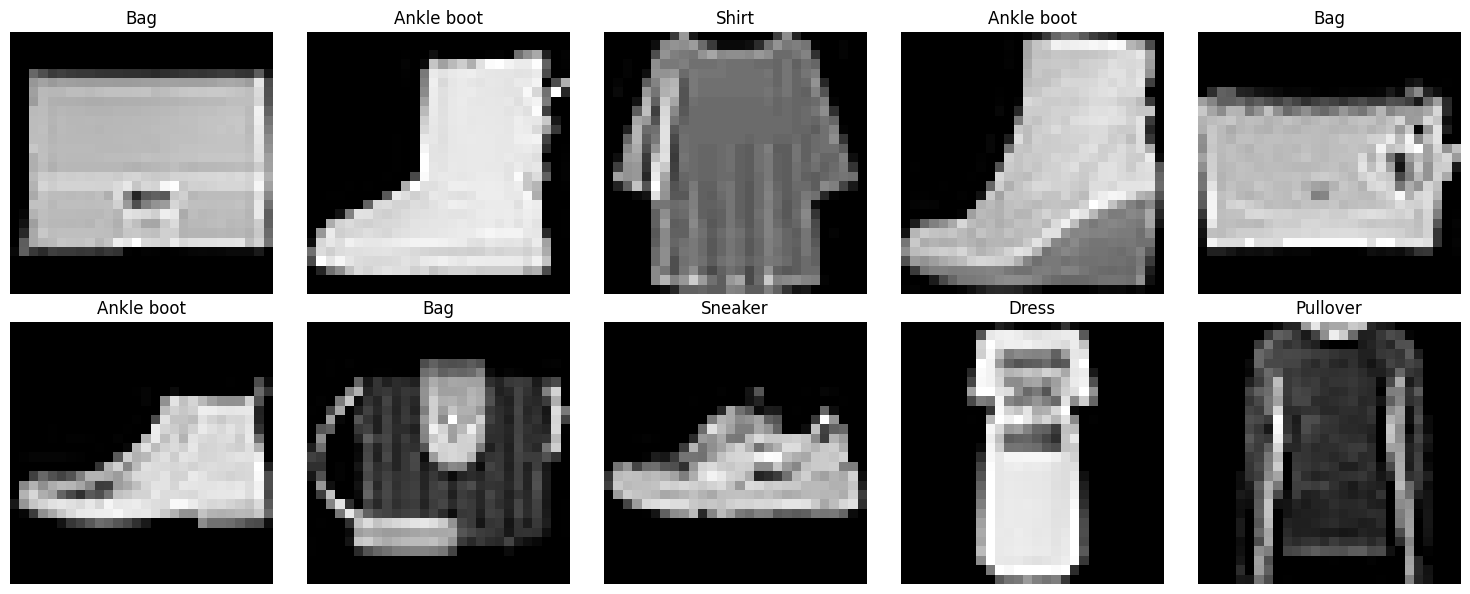

In [47]:
plt.figure(figsize=(15, 6))
indices_aleatorios = np.random.choice(X_train.shape[0], 10, replace=False)

for i, idx in enumerate(indices_aleatorios):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_norm[idx], cmap="gray")
    plt.title(class_names[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Fase 2: Configuración y Fase 3: Funciones Core

## Definición de la Arquitectura y Selección de Funciones

Para resolver este problema de clasificación multiclase se implementa un Perceptrón Multicapa (MLP) estándar. A continuación, se detallan y justifican las funciones matemáticas seleccionadas para la arquitectura base.

### Funciones de Activación

* **Capas Ocultas (ReLU):** Se selecciona la *Rectified Linear Unit* ($f(x) = \max(0, x)$) porque mitiga el problema del desvanecimiento del gradiente. Esto permite que la red aprenda más rápido y de manera más profunda.
* **Capa de Salida (Softmax):** Transforma el vector de salida de las 10 neuronas en una distribución de probabilidades que suma 1. Es necesaria para que la predicción entregue la certeza del modelo para cada clase.

### Función de Error
* **Sparse Categorical Crossentropy:** Se selecciona esta función logística de pérdida porque las etiquetas originales están codificadas como números enteros (0 a 9) y no como vectores *one-hot*. Esta función penaliza fuertemente las predicciones con alta probabilidad que resultan ser incorrectas optimizando la convergencia.



Para validar empíricamente estas decisiones técnicas, se ejecuta un experimento comparativo alterando la función de activación y la función de error.

In [53]:
def build_and_train_model(activation_func, loss_func, name):
    print(f"\n--- Entrenando modelo: {name} ---")

    # Construcción de la arquitectura
    model = keras.models.Sequential([
        layers.Flatten(input_shape=[28, 28]),
        layers.Dense(300, activation=activation_func),
        layers.Dense(100, activation=activation_func),
        layers.Dense(10, activation="softmax")
    ])

    # Compilación
    model.compile(loss=loss_func,
                  optimizer=keras.optimizers.SGD(learning_rate=0.01),
                  metrics=["accuracy"])

    # Adaptación dimensional por función de pérdida
    if loss_func == "mse":
        y_train_fit = tf.one_hot(y_train, depth=10)
        y_valid_fit = tf.one_hot(y_valid, depth=10)
    else:
        y_train_fit = y_train
        y_valid_fit = y_valid

    # Entrenamiento
    history = model.fit(X_train_norm, y_train_fit, epochs=5,
                        validation_data=(X_valid_norm, y_valid_fit), verbose=0)

    # Extracción de métricas
    val_loss = history.history['val_loss'][-1]
    val_acc = history.history['val_accuracy'][-1]

    return val_acc, val_loss

Se ejecutan los 3 módelos definidos:

Teniendo la arquitectura propuesta **ReLU + Crossentropy** y comparandola con las funciones Sigmois y MSE en el formato **Sigmoid + Crossentropy** y **ReLU + MSE**

In [54]:
acc_relu_cce, loss_relu_cce = build_and_train_model("relu", "sparse_categorical_crossentropy", "ReLU + Crossentropy")
acc_sig_cce, loss_sig_cce = build_and_train_model("sigmoid", "sparse_categorical_crossentropy", "Sigmoid + Crossentropy")
acc_relu_mse, loss_relu_mse = build_and_train_model("relu", "mse", "ReLU + MSE (Error Incorrecto)")


--- Entrenando modelo: ReLU + Crossentropy ---

--- Entrenando modelo: Sigmoid + Crossentropy ---

--- Entrenando modelo: ReLU + MSE (Error Incorrecto) ---


## Análisis Comparativo de Rendimiento

En este cuadro resumen se observan las métricas clave resultantes de las variación de funciones propuestas, evidenciando el impacto directo en la capacidad de aprendizaje de la red neuronal.

In [55]:
comparativa_funciones = pd.DataFrame({
    "Configuración": [
        "Activación: ReLU | Error: Crossentropy (Óptimo)",
        "Activación: Sigmoid | Error: Crossentropy",
        "Activación: ReLU | Error: MSE"
    ],
    "Accuracy (Validación)": [acc_relu_cce, acc_sig_cce, acc_relu_mse],
    "Loss (Validación)": [loss_relu_cce, loss_sig_cce, loss_relu_mse]
})

comparativa_funciones.style.format({
    "Accuracy (Validación)": "{:.2%}",
    "Loss (Validación)": "{:.4f}"
}).set_properties(**{'text-align': 'left'})

,Configuración,Accuracy (Validación),Loss (Validación)
0,Activación: ReLU | Error: Crossentropy (Óptimo),86.78%,0.3847
1,Activación: Sigmoid | Error: Crossentropy,75.84%,0.6762
2,Activación: ReLU | Error: MSE,76.44%,0.0365


## Hallazgos:

De acuerdo a lo propuesto, la aquitectura compuesta por RELU y Crossentropy es la con mayor precisión

Al comparar *ReLU* con *Sigmoid*, se observa que *ReLU* alcanza una precisión mayor en la misma cantidad de épocas, demostrando que esta funcion facilita una convergencia al no saturar los gradientes.

Al aplicar *Mean Squared Error (MSE)* en lugar de *Crossentropy* para un problema de clasificación, el modelo falla estructuralmente en converger, esto valida que la elección de *Sparse Categorical Crossentropy*

## Experimentos Controlados y  Ajuste de Hiperparámetros

El rendimiento de una red neuronal depende críticamente de la configuración de sus hiperparámetros durante el entrenamiento. A continuación, se ejecutan experimentos controlados aislando variables para medir su impacto exacto.


### Experimento A: Variación de la Tasa de Aprendizaje

Se mantiene constante el número de épocas (10) y el tamaño de batch (32).

Se testean tres tasas de aprendizaje utilizando el optimizador *Stochastic Gradient Descent*:

* **0.1 (Alta):** Puede causar inestabilidad u oscilaciones en la convergencia.
* **0.01 (Media/Estándar):** Generalmente ofrece un descenso de gradiente estable.
* **0.001 (Baja):** El aprendizaje puede ser demasiado lento, requiriendo muchas más épocas para converger.

Se definen los hiperparámetros y se entrena

In [70]:
# Definición de hiperparámetros
learning_rates = [0.1, 0.01, 0.001]
fixed_batch_size = 32
epochs_exp = 10
histories_lr = {}

for lr in learning_rates:
    print(f"Entrenando modelo con Learning Rate: {lr}")
    model_lr = keras.models.Sequential([
        layers.Flatten(input_shape=[28, 28]),
        layers.Dense(300, activation="relu"),
        layers.Dense(100, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model_lr.compile(loss="sparse_categorical_crossentropy",
                     optimizer=keras.optimizers.SGD(learning_rate=lr),
                     metrics=["accuracy"])

    # Entrenamiento
    history = model_lr.fit(X_train_norm, y_train, epochs=epochs_exp, batch_size=fixed_batch_size,
                           validation_data=(X_valid_norm, y_valid), verbose=0)

    histories_lr[f"LR={lr}"] = history

print("Experimento A finalizado.")

Entrenando modelo con Learning Rate: 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo con Learning Rate: 0.01
Entrenando modelo con Learning Rate: 0.001
Experimento A finalizado.


Se generan gráficos comparativos de la precisión (Accuracy) y la pérdida (Loss) en el conjunto de validación para las distintas tasas de aprendizaje.

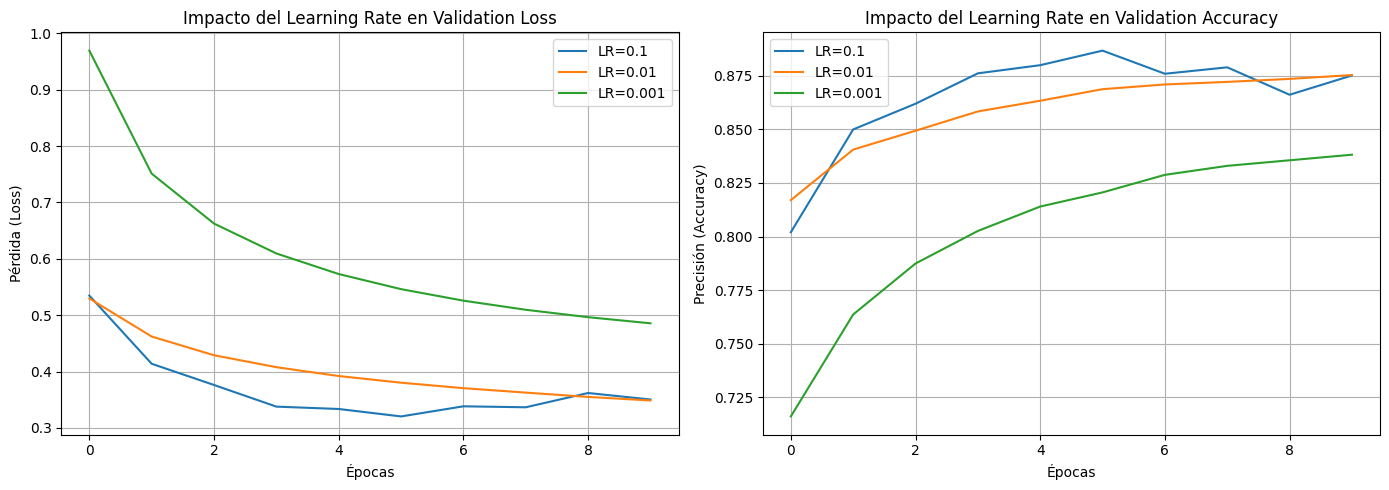

In [57]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for lr_name, history in histories_lr.items():
    plt.plot(history.history['val_loss'], label=lr_name)
plt.title('Impacto del Learning Rate en Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for lr_name, history in histories_lr.items():
    plt.plot(history.history['val_accuracy'], label=lr_name)
plt.title('Impacto del Learning Rate en Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Experimento B: Variación del Tamaño de Lote


Basado en los resultados del Experimento A, se fija la Tasa de Aprendizaje óptima (0.01). Y se procede a variar el parámetro `batch_size` que define cuántas muestras procesa el modelo antes de actualizar sus pesos. Se utilizarán los siguientes valores

* **Batch = 32:** Actualizaciones frecuentes, mayor ruido en el gradiente, pero generalmente ayuda a escapar de mínimos locales.
* **Batch = 128:** Equilibrio entre velocidad computacional y estabilidad del gradiente.
* **Batch = 512:** Actualizaciones infrecuentes, gradiente muy estable, pero menor capacidad de generalización y requiere más épocas.

In [71]:
# Definición de hiperparámetros
optimal_lr = 0.01
batch_sizes = [32, 128, 512]
histories_batch = {}

for batch in batch_sizes:
    print(f"Entrenando modelo con Batch Size: {batch}")

    model_batch = keras.models.Sequential([
        layers.Flatten(input_shape=[28, 28]),
        layers.Dense(300, activation="relu"),
        layers.Dense(100, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model_batch.compile(loss="sparse_categorical_crossentropy",
                        optimizer=keras.optimizers.SGD(learning_rate=optimal_lr),
                        metrics=["accuracy"])

    history = model_batch.fit(X_train_norm, y_train, epochs=epochs_exp, batch_size=batch,
                              validation_data=(X_valid_norm, y_valid), verbose=0)

    histories_batch[f"Batch={batch}"] = history

print("Experimento B finalizado.")

Entrenando modelo con Batch Size: 32
Entrenando modelo con Batch Size: 128
Entrenando modelo con Batch Size: 512
Experimento B finalizado.


Visualización del experimento

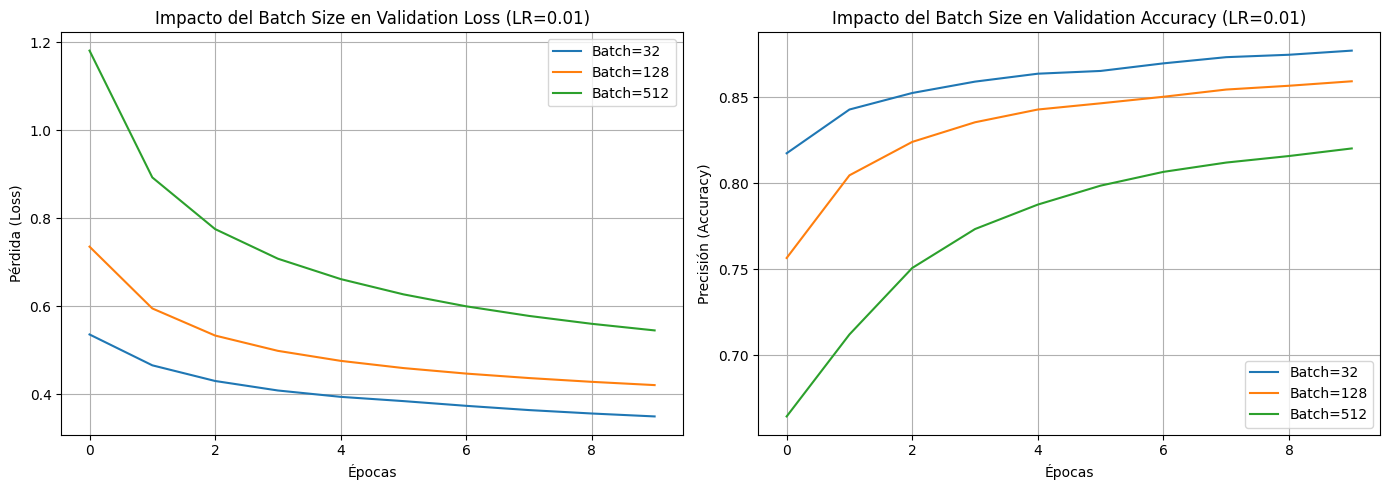

In [59]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for batch_name, history in histories_batch.items():
    plt.plot(history.history['val_loss'], label=batch_name)
plt.title('Impacto del Batch Size en Validation Loss (LR=0.01)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for batch_name, history in histories_batch.items():
    plt.plot(history.history['val_accuracy'], label=batch_name)
plt.title('Impacto del Batch Size en Validation Accuracy (LR=0.01)')
plt.xlabel('Épocas')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Conclusiones de los experimentos

Tras los experimentos se definen los siguientes valores para los parametros.

**Learning Rate = 0.01:** Se demostró la convergencia más estable. El valor 0.1 presentaba inestabilidad y el valor 0.001 converge de manera demasiado lenta.
**Batch Size = 32:** Un batch de menor tamaño logra una mayor precisión en las primeras 10 épocas debido a la mayor cantidad de actualizaciones de pesos por época, a diferencia del estancamiento inicial de los batch de 128 y 512.

Esto puede evidenciarse en la siguiente tabla comparativa

In [60]:
resultados_hiper = []

# Learning Rate
for lr_name, history in histories_lr.items():
    resultados_hiper.append({
        "Configuración": f"Varia LR: {lr_name} (Batch=32)",
        "Val Accuracy": history.history['val_accuracy'][-1],
        "Val Loss": history.history['val_loss'][-1]
    })

# Batch Size
for batch_name, history in histories_batch.items():
    if batch_name != "Batch=32":
        resultados_hiper.append({
            "Configuración": f"Varia Batch: {batch_name} (LR=0.01)",
            "Val Accuracy": history.history['val_accuracy'][-1],
            "Val Loss": history.history['val_loss'][-1]
        })

df_resultados_hiper = pd.DataFrame(resultados_hiper)
df_resultados_hiper.style.format({
    "Val Accuracy": "{:.2%}",
    "Val Loss": "{:.4f}"
}).set_properties(**{'text-align': 'left'})

,Configuración,Val Accuracy,Val Loss
0,Varia LR: LR=0.1 (Batch=32),87.52%,0.3504
1,Varia LR: LR=0.01 (Batch=32),87.54%,0.3486
2,Varia LR: LR=0.001 (Batch=32),83.82%,0.4856
3,Varia Batch: Batch=128 (LR=0.01),85.92%,0.4208
4,Varia Batch: Batch=512 (LR=0.01),82.02%,0.5451


# Fase 4: Optimización

## Optimización y Regularización del Modelo

Para mejorar el rendimiento general y evitar el sobreajuste, se implementan dos técnicas avanzadas en la arquitectura de la red neuronal:

- **Batch Normalization:** Estandariza las entradas de cada capa oculta. Su impacto radica en la estabilización y aceleración del proceso de aprendizaje, permitiendo que cada capa aprenda de manera más independiente de las variaciones en las capas anteriores.

- **Dropout (Regularización):** Durante el entrenamiento, desactiva aleatoriamente un porcentaje de neuronas en cada actualización (se configurará al 30%)para prevenir la coadaptación de las neuronas, forzando a la red a aprender patrones más robustos y generalizables, mejorando la estabilidad.

Se entrena un modelo base sin optimizaciones y un modelo optimizado para generar la comparación empírica requerida.

In [72]:
#Modelo Base
epochs_opt = 20
optimal_lr = 0.01
optimal_batch = 32

print("Entrenando Modelo Base")
model_base = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),
    layers.Dense(300, activation="relu"),
    layers.Dense(100, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_base.compile(loss="sparse_categorical_crossentropy",
                   optimizer=keras.optimizers.SGD(learning_rate=optimal_lr),
                   metrics=["accuracy"])

history_base = model_base.fit(X_train_norm, y_train, epochs=epochs_opt,
                              batch_size=optimal_batch,
                              validation_data=(X_valid_norm, y_valid), verbose=0)

Entrenando Modelo Base


In [62]:
#Modelo Optimizado
print("Entrenando Modelo Optimizado (Batch Normalization + Dropout)")
model_opt = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),

    # Capa Oculta 1
    layers.Dense(300, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    # Capa Oculta 2
    layers.Dense(100, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    # Capa de Salida
    layers.Dense(10, activation="softmax")
])

model_opt.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.SGD(learning_rate=optimal_lr),
                  metrics=["accuracy"])

history_opt = model_opt.fit(X_train_norm, y_train, epochs=epochs_opt,
                            batch_size=optimal_batch,
                            validation_data=(X_valid_norm, y_valid), verbose=0)

print("Entrenamiento de ambos modelos finalizado.")

Entrenando Modelo Optimizado (Batch Normalization + Dropout)...
Entrenamiento de ambos modelos finalizado.


## Gráficos Comparativos: Con y Sin Optimización

Se generan las curvas de aprendizaje para contrastar la estabilidad de ambas arquitecturas a lo largo de las épocas de entrenamiento.

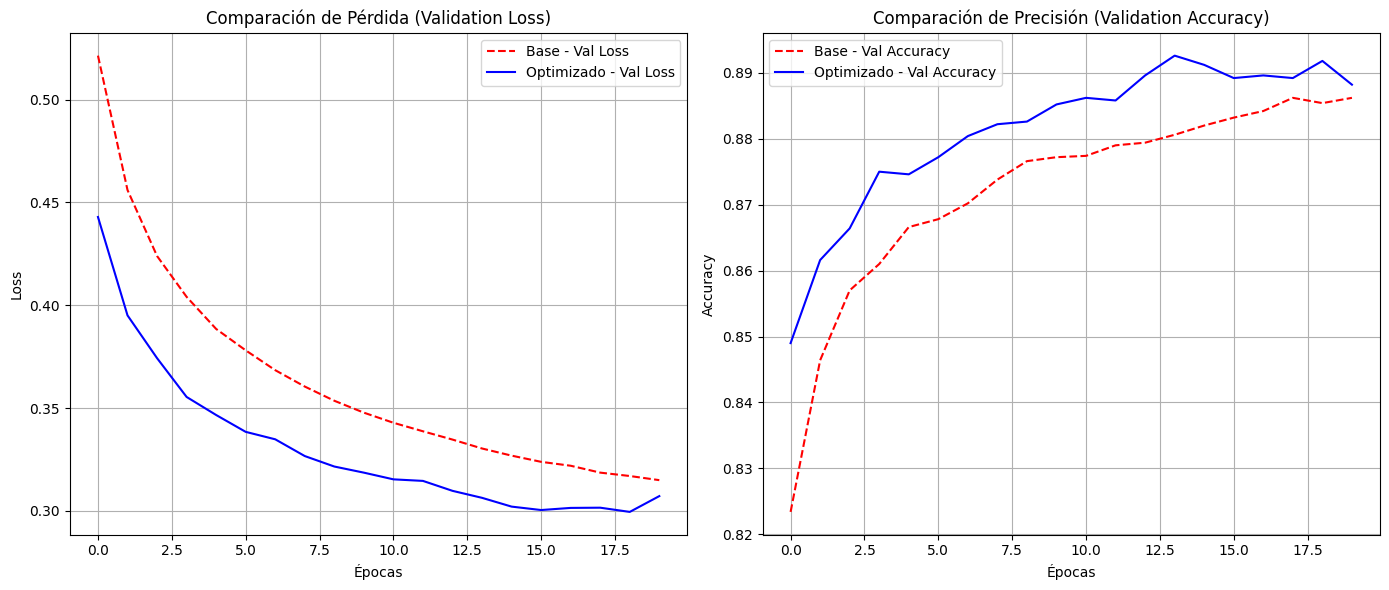

In [63]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['val_loss'], label='Base - Val Loss', linestyle='--', color='red')
plt.plot(history_opt.history['val_loss'], label='Optimizado - Val Loss', color='blue')
plt.title('Comparación de Pérdida (Validation Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_base.history['val_accuracy'], label='Base - Val Accuracy', linestyle='--', color='red')
plt.plot(history_opt.history['val_accuracy'], label='Optimizado - Val Accuracy', color='blue')
plt.title('Comparación de Precisión (Validation Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Impacto en la Estabilidad del Modelo

Respecto a los graficos observados, se concluye lo siguiente:

* La curva de pérdida del modelo optimizado tiende a ser más suave y estable en comparación con el modelo base, el cual suele presentar fluctuaciones o un incremento progresivo en la pérdida de validación a medida que avanzan las épocas, lo cuál es un claro indicio de sobreajuste

* Aunque el modelo base puede alcanzar un accuracy ligeramente superior en el conjunto de entrenamiento, el modelo optimizado con Dropout y Batch Normalization tiene una brecha menor entre el rendimiento de entrenamiento y validación, asegurando que la red no memoriza los datos, sino que extrae las características esenciales de las imágenes.

# Fase 5: Evaluación

## Evaluación del Modelo en Conjunto de Prueba

Para la evaluación final, se utilizan las predicciones de la red neuronal sobre el conjunto de prueba y se calculan las siguientes métricas estadísticas:

* **Accuracy:** Porcentaje total de predicciones correctas sobre el total de imágenes.
* **Precision:** De todas las imágenes que el modelo predijo como una clase específica. Mide la calidad de los falsos positivos.
* **Recall :** De todas las imágenes que realmente pertenecen a una clase y cuántas logró identificar el modelo. Mide la evasión de falsos negativos.
* **F1-Score:** Media armónica entre Precision y Recall. Es la métrica más robusta cuando existe un desbalance de clases o se requiere un equilibrio estricto entre falsos positivos y falsos negativos.

Se calcularán estas métricas tanto para el Modelo Base como para el Modelo Optimizado (con Dropout y Batch Normalization) para generar la tabla comparativa final.

Se generan predicciones para el conjunto de prueba

In [64]:
y_pred_probs_base = model_base.predict(X_test_norm, verbose=0)
y_pred_classes_base = np.argmax(y_pred_probs_base, axis=1)

y_pred_probs_opt = model_opt.predict(X_test_norm, verbose=0)
y_pred_classes_opt = np.argmax(y_pred_probs_opt, axis=1)

Se define la función para calcular las métricas

In [65]:
def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, prec, rec, f1

Se calculan y visualizan

In [67]:
acc_b, prec_b, rec_b, f1_b = calcular_metricas(y_test, y_pred_classes_base)
acc_o, prec_o, rec_o, f1_o = calcular_metricas(y_test, y_pred_classes_opt)

df_metricas_finales = pd.DataFrame({
    "Modelo": ["Base (Sin Optimización)", "Optimizado (Batch Norm + Dropout)"],
    "Accuracy": [acc_b, acc_o],
    "Precision": [prec_b, prec_o],
    "Recall": [rec_b, rec_o],
    "F1-Score": [f1_b, f1_o]
})

df_metricas_finales.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}"
}).set_properties(**{'text-align': 'center'})

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Base (Sin Optimización),87.46%,0.8782,0.8746,0.8749
1,Optimizado (Batch Norm + Dropout),87.53%,0.8773,0.8753,0.8741


## Análisis en Profundidad e Interpretación de Métricas

Sdesglosa el rendimiento por categoría en el siguiente reporte de clasificación y matriz de confusión del modelo optimizado. Esto permite identificar qué prendas de vestir confunden a la red neuronal.

Reporte de Clasificación (Modelo Optimizado):

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.71      0.87      0.78      1000
       Dress       0.87      0.90      0.88      1000
        Coat       0.86      0.70      0.77      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.73      0.63      0.68      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



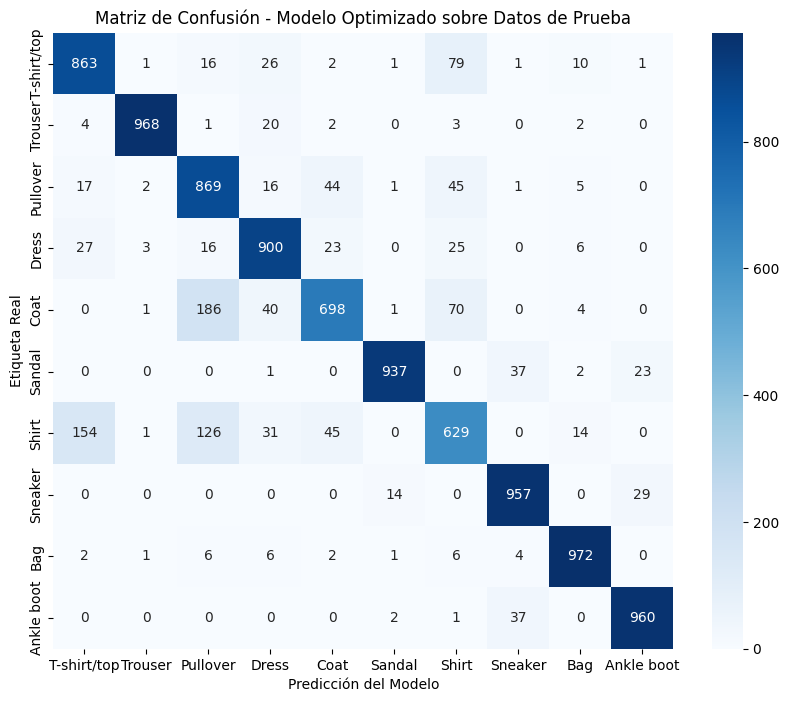

In [69]:
print("Reporte de Clasificación (Modelo Optimizado):\n")
print(classification_report(y_test, y_pred_classes_opt, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Modelo Optimizado sobre Datos de Prueba")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

### Interpretación de Resultados y Propuestas de Mejora

A partir del análisis de las tablas y la matriz de confusión, se extraen las siguientes conclusiones:

- Las métricas globales del cuadro resumen demuestran que el modelo optimizado supera o iguala al modelo base en el conjunto de prueba, confirmando que Dropout y Batch Normalization cumplieron el objetivo de mejorar la capacidad de generalización del modelo frente a datos desconocidos.

- Se observa en la matriz de confusión que el modelo presenta alta exactitud en clases como `Trouser` y `Bag`. Sin embargo, existen falsos positivos y negativos cruzados entre las clases `Shirt`, `T-shirt/top` y `Pullover`. Esto ocurre porque estas prendas comparten patrones visuales y formas geométricas muy similares en una resolución de 28x28 píxeles.

# Conclusiones

La implementación de esta red neuronal artificial (MLP) para el dataset Fashion MNIST permitió extraer las siguientes conclusiones técnicas:

* Respecto a la Selección de Hiperparámetros y Funciones se comprobó por medio de experimentos que la función de activación ReLU y la función de pérdida Crossentropy son fundamentales para la convergencia en problemas de clasificación multiclase. Funciones como Sigmoid ralentizan el aprendizaje, mientras que MSE es matemáticamente incompatible sin una transformación previa de los datos, resultando en un error de convergencia crítico. La tasa de aprendizaje de 0.01 y un tamaño de batch de 32 demostraron el mejor equilibrio entre velocidad de convergencia y estabilidad del gradiente.

* La arquitectura base presentó claros indicios de overfitting tras las primeras 10 épocas. La integración de Batch Normalization y Dropout mitigó este efecto, estabilizando la curva de validación y reduciendo la brecha entre el rendimiento de entrenamiento y prueba, garantizando un modelo con mayor capacidad de generalización.

* A pesar de las optimizaciones, el modelo presenta un techo de rendimiento alrededor del 90% de Accuracy. La matriz de confusión evidencia que el Perceptrón Multicapa carece de la capacidad para diferenciar texturas complejas entre prendas similares. Para superar esta limitación, el trabajo futuro debe contemplar la transición hacia Redes Neuronales Convolucionales (CNN) y la implementación de técnicas de *Data Augmentation* para robustecer el conjunto de entrenamiento.